# Phase 2 Expansion: Scale to 6 Attributes

**Runs on local Jupyter - no GPU needed.**

Adds ~1,100 new samples to the existing dataset:
- **Count (3 -> 300):** synthetic counting grids
- **Shape (5 -> 300):** synthetic objects in canonical vs non-canonical shapes
- **MMStar Fine-grained (~250):** recolored images from MMStar's fine-grained perception category (object location, object counting, attribute recognition)
- **MMStar Coarse (~250):** recolored images from MMStar's coarse perception category (image emotion, style & quality, scene & topic)

Final table attributes: Color, Size, Count, Shape, MMStar-Finegrained, MMStar-Coarse

## 0. Setup

In [1]:
import sys
!{sys.executable} -m pip install -q datasets pillow numpy pandas matplotlib

import os, csv, json, math, random, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

# ── paths ─────────────────────────────────────────────────────
DATASET_DIR = Path("./arbitration_dataset")
IMAGES_DIR  = DATASET_DIR / "images"
META_PATH   = DATASET_DIR / "metadata.csv"

assert META_PATH.exists(), f"metadata.csv not found at {META_PATH}"

existing_df = pd.read_csv(META_PATH)
print(f"existing dataset: {len(existing_df)} samples")
print(existing_df["attribute"].value_counts().to_string())

NEW_METADATA = []

def register_sample(sample_id, attribute, obj, question,
                    visual_answer, prior_answer,
                    cf_image_path, std_image_path, source):
    NEW_METADATA.append({
        "sample_id": sample_id, "attribute": attribute, "object": obj,
        "question": question, "visual_answer": visual_answer,
        "prior_answer": prior_answer, "cf_image": str(cf_image_path),
        "std_image": str(std_image_path), "source": source,
    })

def save_image(img, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    img.save(str(path))
    return str(path)

print("ready")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
existing dataset: 1280 samples
attribute
size            727
color           493
mmstar_color     52
shape             5
count             3
ready


## 1. Count expansion (-> 300 synthetic)

count samples generated: 300


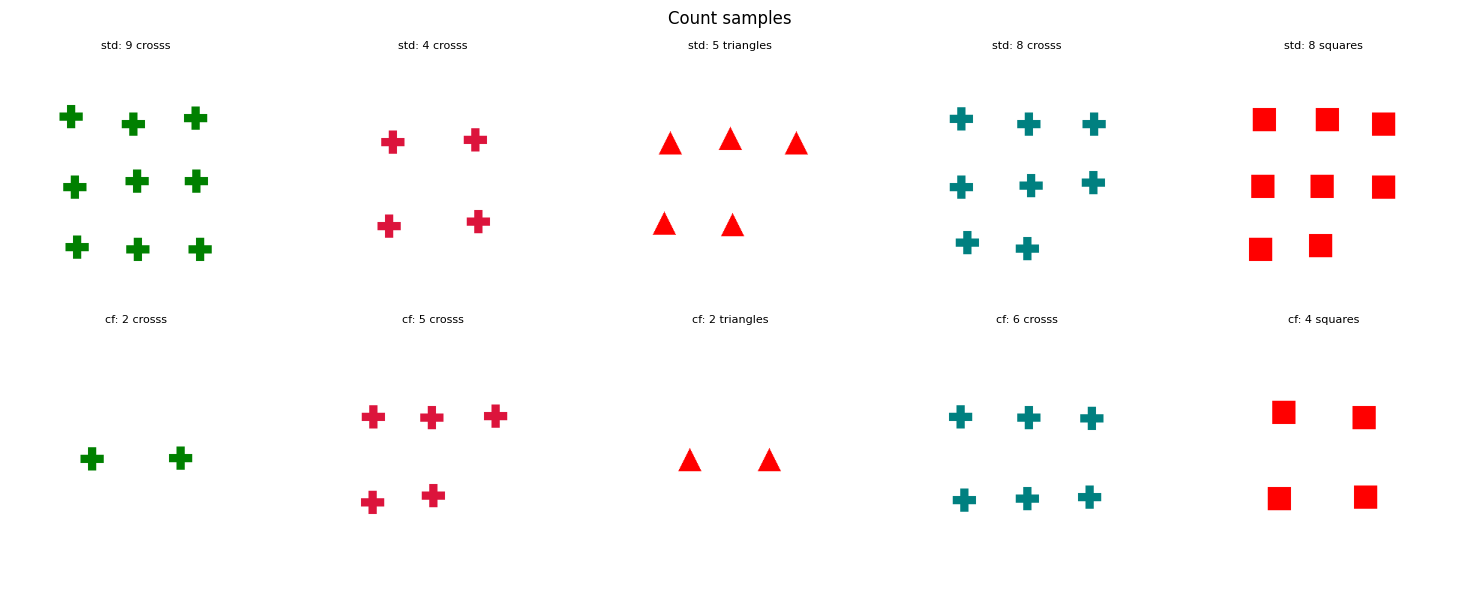

In [2]:
TARGET_COUNT = 300

def draw_shape(draw, shape, cx, cy, size, color):
    r = size // 2
    if shape == "circle":
        draw.ellipse([cx-r, cy-r, cx+r, cy+r], fill=color)
    elif shape == "square":
        draw.rectangle([cx-r, cy-r, cx+r, cy+r], fill=color)
    elif shape == "triangle":
        points = [(cx, cy-r), (cx-r, cy+r), (cx+r, cy+r)]
        draw.polygon(points, fill=color)
    elif shape == "star":
        points = []
        for i in range(10):
            angle = math.pi/2 + i * math.pi/5
            rad = r if i % 2 == 0 else r * 0.4
            points.append((cx + rad * math.cos(angle), cy - rad * math.sin(angle)))
        draw.polygon(points, fill=color)
    elif shape == "diamond":
        points = [(cx, cy-r), (cx+r, cy), (cx, cy+r), (cx-r, cy)]
        draw.polygon(points, fill=color)
    elif shape == "cross":
        w = r // 3
        draw.rectangle([cx-w, cy-r, cx+w, cy+r], fill=color)
        draw.rectangle([cx-r, cy-w, cx+r, cy+w], fill=color)

def generate_count_image(count, shape, color, img_size=336, obj_size=30):
    img = Image.new("RGB", (img_size, img_size), "white")
    draw = ImageDraw.Draw(img)
    cols = max(1, math.ceil(math.sqrt(count)))
    rows = max(1, math.ceil(count / cols))
    sx = img_size // (cols + 1)
    sy = img_size // (rows + 1)
    placed = 0
    for ri in range(rows):
        for ci in range(cols):
            if placed >= count:
                break
            cx = sx * (ci + 1) + random.randint(-5, 5)
            cy = sy * (ri + 1) + random.randint(-5, 5)
            draw_shape(draw, shape, cx, cy, obj_size, color)
            placed += 1
    return img

SHAPES = ["circle", "square", "triangle", "star", "diamond", "cross"]
COLORS = ["red", "blue", "green", "orange", "purple", "brown", "black", "navy", "crimson", "teal"]
SHAPE_NAMES = {"circle": "circles", "square": "squares", "triangle": "triangles",
               "star": "stars", "diamond": "diamonds", "cross": "crosses"}

(IMAGES_DIR / "count_synth").mkdir(parents=True, exist_ok=True)

count_pairs = []
for shape in SHAPES:
    for std_c in range(2, 10):
        for cf_c in range(2, 10):
            if cf_c != std_c:
                count_pairs.append((shape, std_c, cf_c))

random.shuffle(count_pairs)
count_pairs = count_pairs[:TARGET_COUNT]

count_reg = 0
for shape, std_c, cf_c in count_pairs:
    color = random.choice(COLORS)
    obj_name = SHAPE_NAMES[shape]
    std_img = generate_count_image(std_c, shape, color)
    cf_img  = generate_count_image(cf_c, shape, color)
    sid = f"count_synth_{count_reg + 1:04d}"
    cf_path  = save_image(cf_img, IMAGES_DIR / "count_synth" / f"{sid}_cf.png")
    std_path = save_image(std_img, IMAGES_DIR / "count_synth" / f"{sid}_std.png")
    register_sample(sid, "count", obj_name, f"How many {obj_name} are in the image?",
                   str(cf_c), str(std_c), cf_path, std_path, "synthetic_count")
    count_reg += 1

print(f"count samples generated: {count_reg}")

# preview
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for j in range(5):
    sh, sc, cc = count_pairs[j]
    col = random.choice(COLORS)
    axes[0,j].imshow(generate_count_image(sc, sh, col)); axes[0,j].set_title(f"std: {sc} {sh}s", fontsize=8); axes[0,j].axis("off")
    axes[1,j].imshow(generate_count_image(cc, sh, col)); axes[1,j].set_title(f"cf: {cc} {sh}s", fontsize=8); axes[1,j].axis("off")
plt.suptitle("Count samples"); plt.tight_layout()
plt.savefig(DATASET_DIR / "count_preview.png", dpi=110); plt.show()

## 2. Shape expansion (-> 300 synthetic)

shape samples generated: 300


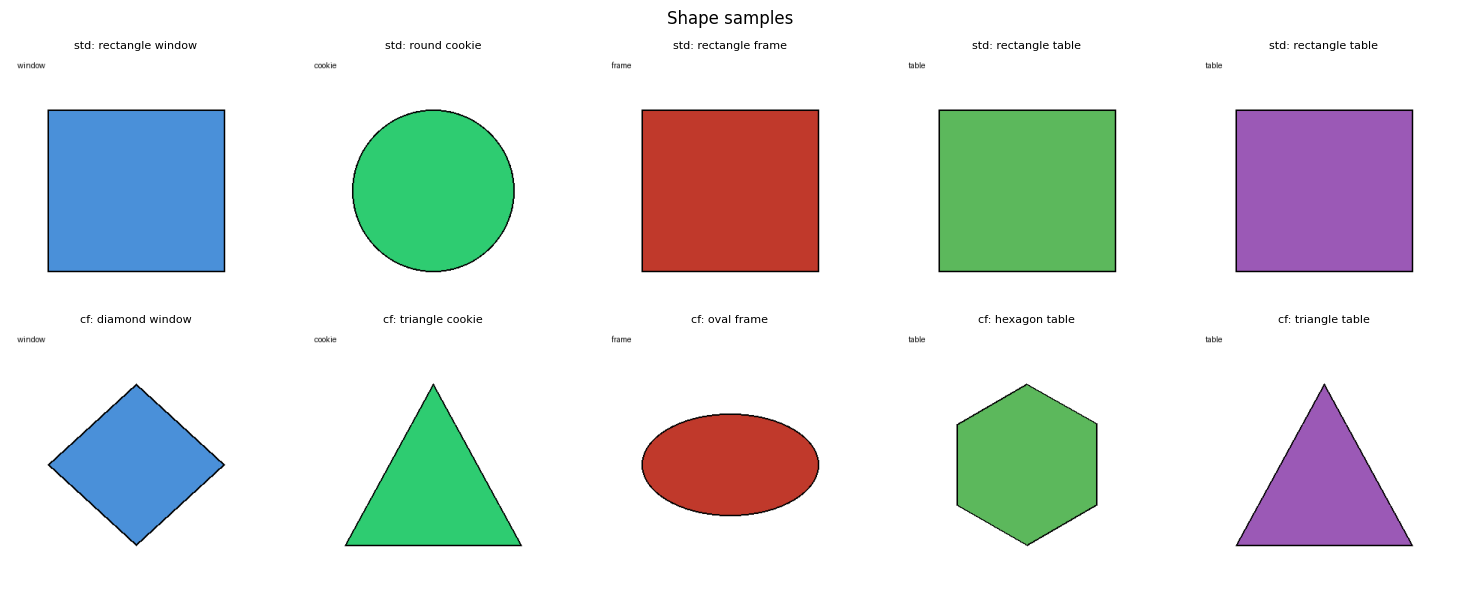

In [3]:
TARGET_SHAPE = 300

def draw_object_in_shape(obj_type, shape, fill_color, img_size=336):
    img = Image.new("RGB", (img_size, img_size), "white")
    draw = ImageDraw.Draw(img)
    margin = 50
    x0, y0 = margin, margin + 20
    x1, y1 = img_size - margin, img_size - margin
    cx, cy = img_size // 2, (y0 + y1) // 2

    if shape in ("round", "circle"):
        r = min(x1-x0, y1-y0) // 2
        draw.ellipse([cx-r, cy-r, cx+r, cy+r], fill=fill_color, outline="black", width=2)
    elif shape in ("square", "rectangle"):
        draw.rectangle([x0, y0, x1, y1], fill=fill_color, outline="black", width=2)
    elif shape == "triangle":
        draw.polygon([(cx, y0), (x0, y1), (x1, y1)], fill=fill_color, outline="black", width=2)
    elif shape == "oval":
        draw.ellipse([x0, y0+40, x1, y1-40], fill=fill_color, outline="black", width=2)
    elif shape == "hexagon":
        r = min(x1-x0, y1-y0) // 2
        pts = [(cx + r*math.cos(math.pi/3*i + math.pi/6), cy + r*math.sin(math.pi/3*i + math.pi/6)) for i in range(6)]
        draw.polygon(pts, fill=fill_color, outline="black", width=2)
    elif shape == "diamond":
        draw.polygon([(cx, y0), (x1, cy), (cx, y1), (x0, cy)], fill=fill_color, outline="black", width=2)
    draw.text((10, 5), obj_type, fill="black")
    return img

OBJECT_SHAPE_MAP = [
    ("pizza","round",["square","triangle","hexagon","diamond"]),
    ("clock","round",["square","triangle","hexagon","diamond"]),
    ("plate","round",["square","oval","hexagon","diamond"]),
    ("cookie","round",["square","triangle","hexagon","diamond"]),
    ("mirror","rectangle",["round","oval","hexagon","triangle"]),
    ("window","rectangle",["round","triangle","hexagon","diamond"]),
    ("table","rectangle",["round","oval","triangle","hexagon"]),
    ("sign","rectangle",["round","triangle","hexagon","diamond"]),
    ("cake","round",["square","triangle","hexagon","diamond"]),
    ("coin","round",["square","hexagon","diamond","triangle"]),
    ("frame","rectangle",["round","oval","hexagon","diamond"]),
    ("wheel","round",["square","hexagon","diamond","triangle"]),
]

FILL_COLORS = ["#E8A040","#4A90D9","#5CB85C","#D9534F","#9B59B6",
               "#3498DB","#E74C3C","#2ECC71","#F39C12","#1ABC9C",
               "#8E44AD","#D35400","#C0392B","#16A085","#2980B9"]

(IMAGES_DIR / "shape_synth").mkdir(parents=True, exist_ok=True)

combos = []
for obj, canon, cfs in OBJECT_SHAPE_MAP:
    for cf in cfs:
        for col in FILL_COLORS:
            combos.append((obj, canon, cf, col))
random.shuffle(combos)
combos = combos[:TARGET_SHAPE]

shape_reg = 0
for obj, canon, cf_sh, col in combos:
    std_img = draw_object_in_shape(obj, canon, col)
    cf_img  = draw_object_in_shape(obj, cf_sh, col)
    sid = f"shape_synth_{shape_reg + 1:04d}"
    cf_path  = save_image(cf_img, IMAGES_DIR / "shape_synth" / f"{sid}_cf.png")
    std_path = save_image(std_img, IMAGES_DIR / "shape_synth" / f"{sid}_std.png")
    register_sample(sid, "shape", obj, f"What shape is the {obj}?",
                   cf_sh, canon, cf_path, std_path, "synthetic_shape")
    shape_reg += 1

print(f"shape samples generated: {shape_reg}")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for j in range(5):
    o, ca, cf, co = combos[j]
    axes[0,j].imshow(draw_object_in_shape(o, ca, co)); axes[0,j].set_title(f"std: {ca} {o}", fontsize=8); axes[0,j].axis("off")
    axes[1,j].imshow(draw_object_in_shape(o, cf, co)); axes[1,j].set_title(f"cf: {cf} {o}", fontsize=8); axes[1,j].axis("off")
plt.suptitle("Shape samples"); plt.tight_layout()
plt.savefig(DATASET_DIR / "shape_preview.png", dpi=110); plt.show()

## 3. MMStar Perception: Fine-grained (250) + Coarse (250)

Loads all 500 perception samples from MMStar, splits by category, applies the recolor pipeline to generate counterfactual color variants.

- **Fine-grained Perception (250):** object location (40), object counting (92), attribute & celebrity recognition (118)
- **Coarse Perception (250):** image emotion (31), image style & quality (78), image scene & topic (141)

In [4]:
from datasets import load_dataset

# ── recolor utilities ─────────────────────────────────────────
TARGET_HUE_PIL = {
    "red": 0, "orange": 21, "yellow": 42, "green": 85,
    "blue": 150, "purple": 200, "pink": 225, "brown": 15,
}

def dominant_hue(img, bins=32):
    hsv = np.asarray(img.convert("HSV")).astype(np.float64)
    h, s, v = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    mask = (s > 40) & (v > 30) & (v < 256)
    if mask.sum() == 0:
        return None, 0.0
    pct = mask.mean()
    hist, edges = np.histogram(h[mask], bins=bins, range=(0, 256))
    peak = np.argmax(hist)
    lo, hi = edges[max(peak-1, 0)], edges[min(peak+2, bins)]
    refined = h[mask][(h[mask] >= lo) & (h[mask] < hi)]
    if len(refined) == 0:
        return (edges[peak] + edges[peak+1]) / 2, pct
    ang = refined / 256 * 2 * np.pi
    mean_ang = np.arctan2(np.sin(ang).mean(), np.cos(ang).mean())
    return (mean_ang / (2 * np.pi) * 256) % 256, pct

def hue_to_color_name(hue_val):
    if hue_val is None:
        return None
    best, best_d = None, 999
    for color, target in TARGET_HUE_PIL.items():
        d = min(abs(hue_val - target), 256 - abs(hue_val - target))
        if d < best_d:
            best_d = d
            best = color
    return best if best_d < 30 else None

def recolor_to_target(img, target_name):
    if target_name in TARGET_HUE_PIL:
        hue_val, _ = dominant_hue(img)
        if hue_val is None:
            return img
        shift = (TARGET_HUE_PIL[target_name] - hue_val) % 256
        hsv = np.asarray(img.convert("HSV")).astype(np.int16)
        hsv[..., 0] = (hsv[..., 0] + int(shift)) % 256
        return Image.fromarray(hsv.astype(np.uint8), "HSV").convert("RGB")
    elif target_name == "white":
        hsv = np.asarray(img.convert("HSV")).astype(np.int16)
        hsv[..., 1] = (hsv[..., 1] * 0.15).astype(np.int16)
        hsv[..., 2] = np.clip(hsv[..., 2] * 1.6, 0, 255).astype(np.int16)
        return Image.fromarray(hsv.astype(np.uint8), "HSV").convert("RGB")
    elif target_name == "black":
        hsv = np.asarray(img.convert("HSV")).astype(np.int16)
        hsv[..., 2] = np.clip(hsv[..., 2] * 0.15, 0, 255).astype(np.int16)
        return Image.fromarray(hsv.astype(np.uint8), "HSV").convert("RGB")
    elif target_name == "gray":
        hsv = np.asarray(img.convert("HSV")).astype(np.int16)
        hsv[..., 1] = (hsv[..., 1] * 0.1).astype(np.int16)
        return Image.fromarray(hsv.astype(np.uint8), "HSV").convert("RGB")
    return img

def pick_different_color(orig, colors):
    cands = [c for c in colors if c != orig]
    return random.choice(cands) if cands else "blue"

# ── load MMStar ───────────────────────────────────────────────
mmstar = load_dataset("Lin-Chen/MMStar", split="val")
print(f"loaded MMStar: {len(mmstar)} samples")
print(f"columns: {mmstar.column_names}")

# find the category column
cat_col = None
for c in ["category", "l2_category", "meta_info"]:
    if c in mmstar.column_names:
        cat_col = c
        break
print(f"category column: {cat_col}")

# show all categories to verify mapping
if cat_col:
    cats = Counter(str(x) for x in mmstar[cat_col])
    print("\ncategory distribution:")
    for k, v in cats.most_common():
        print(f"  {k:45s} {v}")

loaded MMStar: 1500 samples
columns: ['index', 'question', 'image', 'answer', 'category', 'l2_category', 'meta_info']
category column: category

category distribution:
  coarse perception                             250
  fine-grained perception                       250
  instance reasoning                            250
  logical reasoning                             250
  math                                          250
  science & technology                          250


fine-grained perception: 250 samples (expect 250)
coarse perception:       250 samples (expect 250)

mmstar_finegrained: 231 registered, 19 skipped
mmstar_coarse:      230 registered, 20 skipped


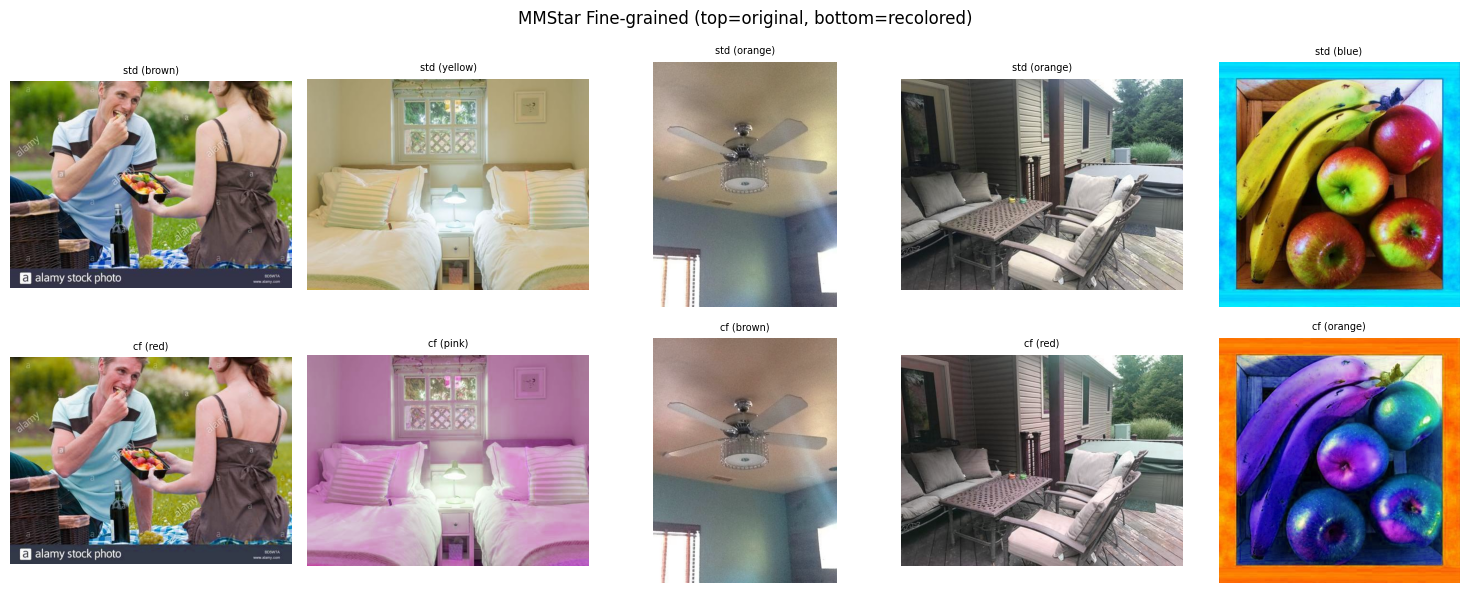

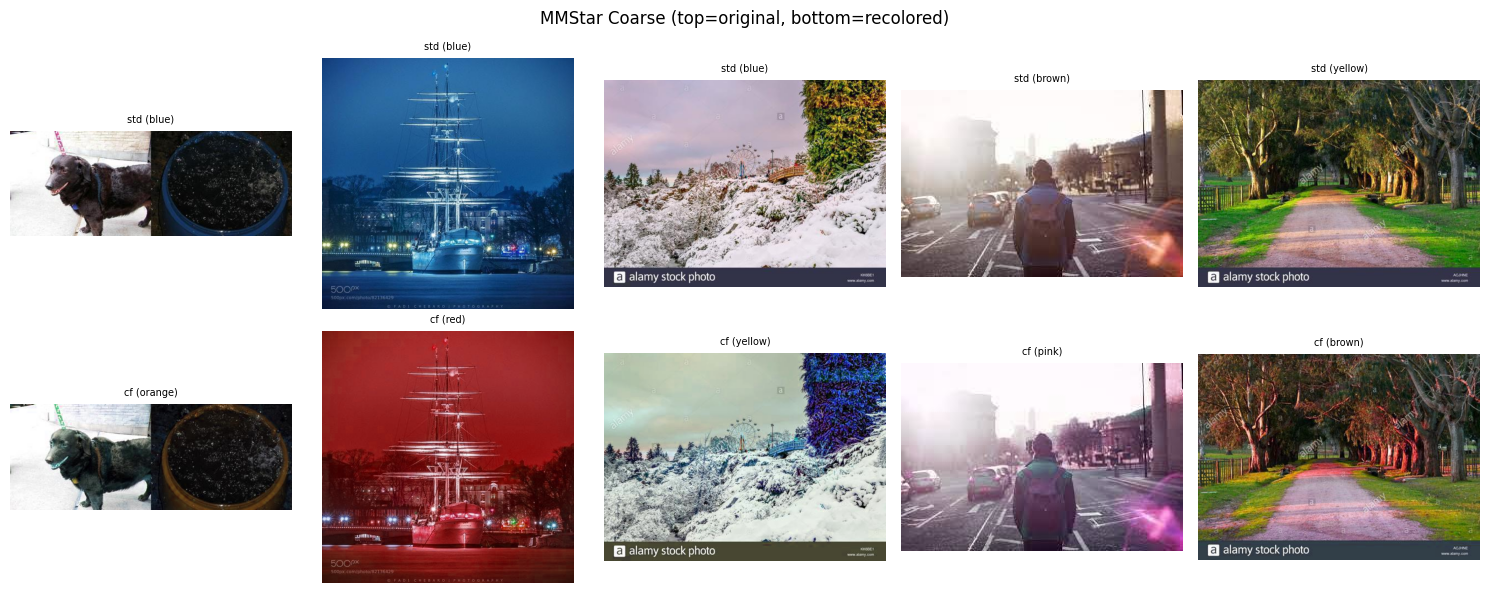

In [6]:
# ── category classification ────────────────────────────────────
FINE_GRAINED_KEYWORDS = ["object location", "object counting", "attribute", "celebrity", "recognition"]
COARSE_KEYWORDS = ["emotion", "style", "quality", "scene", "topic"]

def classify_perception_category(cat_value):
    cat = str(cat_value).lower().strip()
    if cat == "fine-grained perception":
        return "mmstar_finegrained"
    elif cat == "coarse perception":
        return "mmstar_coarse"
    return None

# ── split MMStar into fine-grained and coarse ─────────────────
fine_grained_rows = []
coarse_rows = []

for i in range(len(mmstar)):
    row = mmstar[i]
    cat = str(row.get(cat_col, ""))
    
    label = classify_perception_category(cat)
    if label == "mmstar_finegrained":
        fine_grained_rows.append((i, row))
    elif label == "mmstar_coarse":
        coarse_rows.append((i, row))

print(f"fine-grained perception: {len(fine_grained_rows)} samples (expect 250)")
print(f"coarse perception:       {len(coarse_rows)} samples (expect 250)")

# ── process both categories ───────────────────────────────────
def process_mmstar_category(rows, attribute_name, folder_name):
    out_dir = IMAGES_DIR / folder_name
    out_dir.mkdir(parents=True, exist_ok=True)

    registered = 0
    skipped = 0

    random.shuffle(rows)

    for idx, row in rows:
        img = row.get("image")
        if img is None or not isinstance(img, Image.Image):
            skipped += 1
            continue

        img = img.convert("RGB")
        hue_val, sat_pct = dominant_hue(img)

        if hue_val is None or sat_pct < 0.12:
            skipped += 1
            continue

        prior_color = hue_to_color_name(hue_val)
        if prior_color is None:
            skipped += 1
            continue

        target_color = pick_different_color(prior_color, list(TARGET_HUE_PIL.keys()))
        cf_img = recolor_to_target(img, target_color)

        sid = f"{attribute_name}_{registered + 1:04d}"
        cf_path  = save_image(cf_img, out_dir / f"{sid}_cf.png")
        std_path = save_image(img, out_dir / f"{sid}_std.png")

        register_sample(
            sid, attribute_name, "object",
            "What is the dominant color in this image?",
            visual_answer=target_color,
            prior_answer=prior_color,
            cf_image_path=cf_path,
            std_image_path=std_path,
            source=f"mmstar_{attribute_name}"
        )
        registered += 1

    return registered, skipped

fg_reg, fg_skip = process_mmstar_category(fine_grained_rows, "mmstar_finegrained", "mmstar_finegrained")
co_reg, co_skip = process_mmstar_category(coarse_rows, "mmstar_coarse", "mmstar_coarse")

print(f"\nmmstar_finegrained: {fg_reg} registered, {fg_skip} skipped")
print(f"mmstar_coarse:      {co_reg} registered, {co_skip} skipped")

# preview fine-grained
fg_entries = [m for m in NEW_METADATA if m["attribute"] == "mmstar_finegrained"][:5]
co_entries = [m for m in NEW_METADATA if m["attribute"] == "mmstar_coarse"][:5]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for j, entry in enumerate(fg_entries):
    axes[0,j].imshow(Image.open(entry["std_image"]))
    axes[0,j].set_title(f"std ({entry['prior_answer']})", fontsize=7); axes[0,j].axis("off")
    axes[1,j].imshow(Image.open(entry["cf_image"]))
    axes[1,j].set_title(f"cf ({entry['visual_answer']})", fontsize=7); axes[1,j].axis("off")
plt.suptitle("MMStar Fine-grained (top=original, bottom=recolored)")
plt.tight_layout(); plt.savefig(DATASET_DIR / "mmstar_fg_preview.png", dpi=110); plt.show()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for j, entry in enumerate(co_entries):
    axes[0,j].imshow(Image.open(entry["std_image"]))
    axes[0,j].set_title(f"std ({entry['prior_answer']})", fontsize=7); axes[0,j].axis("off")
    axes[1,j].imshow(Image.open(entry["cf_image"]))
    axes[1,j].set_title(f"cf ({entry['visual_answer']})", fontsize=7); axes[1,j].axis("off")
plt.suptitle("MMStar Coarse (top=original, bottom=recolored)")
plt.tight_layout(); plt.savefig(DATASET_DIR / "mmstar_co_preview.png", dpi=110); plt.show()

## 4. Merge & validate

In [8]:
# remove synthetic count/shape from new samples — keeping only MMStar entries
new_df = pd.DataFrame(NEW_METADATA)
new_df = new_df[new_df["attribute"].isin(["mmstar_finegrained", "mmstar_coarse"])]
print(f"new samples (MMStar only): {len(new_df)}")
print(new_df["attribute"].value_counts().to_string())

# remove old mmstar_color from existing, but KEEP original count(3) and shape(5)
keep_mask = ~existing_df["attribute"].isin(["mmstar_color"])
cleaned_existing = existing_df[keep_mask].copy()
print(f"\nexisting after removing old mmstar_color: {len(cleaned_existing)}")

combined_df = pd.concat([cleaned_existing, new_df], ignore_index=True)
combined_df = combined_df.drop_duplicates(subset="sample_id", keep="first")

combined_df.to_csv(META_PATH, index=False)
print(f"\nupdated metadata.csv: {len(combined_df)} total samples")

print("\n" + "=" * 55)
print("FINAL DATASET SUMMARY")
print("=" * 55)
for attr in ["color", "size", "mmstar_finegrained", "mmstar_coarse", "count", "shape"]:
    n = (combined_df["attribute"] == attr).sum()
    label = "(main)" if attr in ["color","size","mmstar_finegrained","mmstar_coarse"] else "(appendix)"
    print(f"  {attr:22s}: {n:5d} samples  {label}")
print(f"  {'TOTAL':22s}: {len(combined_df):5d}")

dupes = combined_df.duplicated("sample_id").sum()
empty_va = (combined_df["visual_answer"].astype(str).str.strip() == "").sum()
empty_pa = (combined_df["prior_answer"].astype(str).str.strip() == "").sum()
print(f"\nduplicate sample_ids: {dupes}")
print(f"empty visual_answer: {empty_va}")
print(f"empty prior_answer: {empty_pa}")

if dupes == 0 and empty_va == 0 and empty_pa == 0:
    print("\nALL CHECKS PASSED")

new samples (MMStar only): 461
attribute
mmstar_finegrained    231
mmstar_coarse         230

existing after removing old mmstar_color: 1228

updated metadata.csv: 1689 total samples

FINAL DATASET SUMMARY
  color                 :   493 samples  (main)
  size                  :   727 samples  (main)
  mmstar_finegrained    :   231 samples  (main)
  mmstar_coarse         :   230 samples  (main)
  count                 :     3 samples  (appendix)
  shape                 :     5 samples  (appendix)
  TOTAL                 :  1689

duplicate sample_ids: 0
empty visual_answer: 0
empty prior_answer: 0

ALL CHECKS PASSED


In [10]:
import shutil
shutil.make_archive("arbitration_dataset", "zip", DATASET_DIR.parent, DATASET_DIR.name)
size_mb = os.path.getsize("arbitration_dataset.zip") / 1e6
print(f"zipped: arbitration_dataset.zip ({size_mb:.0f} MB)")
print("\nupload to Google Drive, then rerun Notebook A")

zipped: arbitration_dataset.zip (844 MB)

upload to Google Drive, then rerun Notebook A
